# Trabajo Practico 1: Analisis Exploratorio de Datos (EDA)
**Alumno:** Santiago Jorda  
**Materia:** Organizacion de Datos / Ciencia de Datos (FIUBA)  
**Dataset:** NASA Turbofan Engine Degradation Simulation (C-MAPSS)  
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/santiagojorda/ciencia-de-datos-tp1/blob/entrega-tp1/TP1_colab.ipynb)

> **Configuracion para Google Colab:** Si ejecutas este notebook en Google Colab, ejecuta la siguiente celda para clonar automaticamente el repositorio con los datasets e instalar las dependencias requeridas (incluyendo PySpark).

In [ ]:
import sys
import os

# Verificacion y preparacion del entorno en Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Ejecutando en Google Colab: configurando repositorio y dependencias...")
    # Si no existe la carpeta data, clonamos el repositorio publico
    if not os.path.exists('data'):
        !git clone -b entrega-tp1 https://github.com/santiagojorda/ciencia-de-datos-tp1.git
        %cd ciencia-de-datos-tp1
    # Instalamos PySpark en Colab
    !pip install -q pyspark
    print("Entorno de Colab listo con PySpark y datasets.")
else:
    print("Ejecutando en entorno local.")

## Motivacion y seleccion del dataset

Elegi este dataset por un motivo bastante personal. Mi papa es ingeniero electromecanico, trabaja con turbomaquinas hace mas de 30 años y da clases de Maquinas Alternativas y Turbomaquinas en la UTN. Es un tema del que lo escuche hablar toda la vida, asi que cuando encontre este dataset de la NASA que simula el desgaste de motores turbofan hasta que rompen, me llamo la atencion enseguida.

Aclaro igual que yo no vengo de mecanica. Lo que se de turbofans es lo que sale de dos lugares: el readme que viene con el dataset y el paper de la NASA que lo describe (Saxena et al. 2008, "Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation"). Cada vez que digo algo del motor aclaro de cual de los dos sale.

## 1. Configuracion del Entorno e Ingesta de Datos

### 1.1 Diccionario de Datos y Contexto del Problema
Este dataset simula motores turbofan que se van degradando vuelo a vuelo, hasta que rompen.

Para cada escenario (FD001 a FD004), la NASA da 3 archivos. Segun el readme, cada uno cumple una funcion distinta:
* **train:** corridas completas hasta la falla, desde el ciclo 1 hasta que rompe. Es el que uso para el EDA y para entrenar despues.
* **test:** corridas truncadas antes de la falla, no se sabe en que ciclo rompe cada motor. Simula estar monitoreando un motor sin saber cuanto le queda.
* **RUL:** la vida util real que le quedaba a cada motor de test en el momento del corte. Es la respuesta contra la que se compara despues lo que prediga un modelo.

Trabajo principalmente con train. Train y test comparten la misma estructura, 26 columnas numericas sin encabezado:
* **`unit_id` (Columna 1):** identificador del motor (en FD001 van del 1 al 100).
* **`cycle` (Columna 2):** el numero de vuelo del motor, arranca en 1 y suma de a uno por fila, cada fila es un vuelo completo, no una medicion cada tantos segundos. Segun el paper original (Saxena et al. 2008), se mide una vez que el motor llega a un estado estable en la condicion de vuelo fijada (`setting_1` a `setting_3`). El ultimo ciclo es el vuelo en el que rompe.
* **`setting_1` (Columna 3):** altitud de vuelo, en miles de pies.
* **`setting_2` (Columna 4):** numero Mach, la velocidad del avion.
* **`setting_3` (Columna 5):** TRA (throttle resolver angle), el angulo de la palanca de aceleracion.
* **`sensor_1` a `sensor_21` (Columnas 6-26):** las mediciones de los sensores del motor.

El readme a los settings solo los llama "operational setting 1, 2 y 3". Que sean altitud, Mach (velocidad del avion expresada como fraccion de la velocidad de sonido) y TRA (angulo de palanca de aceleracion) lo saco del paper, que nombra esas tres condiciones con sus rangos: altitud de 0 a 42 mil pies, Mach de 0 a 0.84 y TRA de 20 a 100.

### 1.2 Por que arranco por FD001
El repositorio C-MAPSS incluye `FD001` a `FD004`. Segun el readme, cambian en las condiciones de vuelo y en los modos de falla simulados:

| Subdataset | Condiciones operacionales | Modos de falla |
|---|---|---|
| FD001 | 1 (nivel del mar) | 1 (degradacion HPC) |
| FD002 | 6 | 1 (degradacion HPC) |
| FD003 | 1 (nivel del mar) | 2 (HPC + Fan) |
| FD004 | 6 | 2 (HPC + Fan) |

Los modos de falla no los termino de dimensionar. FD003 y FD004 suman una segunda falla y entiendo que eso deberia verse de alguna forma en los sensores.

Por eso arranco por FD001, que es el caso mas simple (una sola condicion de vuelo, una sola falla)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Constantes que uso a lo largo de todo el analisis
CANTIDAD_SENSORES = 21
CICLOS_FASE = 30 

# colores fijos para todo el TP
COLOR_SANA = '#1f77b4'     # azul
COLOR_CRITICA = '#d95f02'  # naranja
COLOR_NEUTRO = '#636363'   # gris

print("Librerias importadas correctamente.")

Librerias importadas correctamente.


### 1.3 Carga de Datos Crudos (`train_FD001.txt`)
Cargo el archivo, separado por espacios en blanco, y le asigno nombres a cada columna.

In [3]:
# Asigno nombre de columnas segun la documentacion de NASA
columnas_sensores = []
for i in range(1, CANTIDAD_SENSORES + 1):
    nombre_columna = f'sensor_{i}'
    columnas_sensores.append(nombre_columna)

nombres_columnas = ['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3'] + columnas_sensores

# Cargo el archivo FD001 de entrenamiento
df = pd.read_csv('data/train_FD001.txt', sep=r'\s+', header=None, names=nombres_columnas)

print(f"Registros totales: {df.shape[0]:,} filas | Atributos: {df.shape[1]} columnas")
print(f"Cantidad de turbinas monitoreadas: {df['unit_id'].nunique()} motores")
df.head(5)

Registros totales: 20,631 filas | Atributos: 26 columnas
Cantidad de turbinas monitoreadas: 100 motores


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 1.4 Verificacion de train, test y RUL con los datos reales
Cargo tambien `test_FD001.txt` y `RUL_FD001.txt` para confirmar con numeros lo que explique antes:

In [4]:
test_df = pd.read_csv('data/test_FD001.txt', sep=r'\s+', header=None, names=nombres_columnas)
rul_df = pd.read_csv('data/RUL_FD001.txt', header=None, names=['RUL'])

# el archivo trae un RUL por motor, en el mismo orden que unit_id
rul_df['unit_id'] = range(1, len(rul_df) + 1) 

ciclos_por_motor_test = test_df.groupby('unit_id')['cycle'].max()

print(f"train: {df.shape[0]} filas, {df['unit_id'].nunique()} motores, cada uno corrido hasta la falla")
print(f"test: {test_df.shape[0]} filas, {test_df['unit_id'].nunique()} motores, series truncadas")
print(f"Ciclos observados en test por motor (min, max): {ciclos_por_motor_test.min()}, {ciclos_por_motor_test.max()}")
print(f"RUL_FD001.txt: {rul_df.shape[0]} valores, uno por motor de test")

# vida util total de cada motor de test: los ciclos que llegue a observar mas los que le quedaban
vida_test = ciclos_por_motor_test.reset_index().merge(rul_df, on='unit_id')
vida_test['vida_estimada'] = vida_test['cycle'] + vida_test['RUL']

vida_media_train = df.groupby('unit_id')['cycle'].max().mean()

print()
print(f"Vida util media estimada en test: {vida_test['vida_estimada'].mean():.1f} ciclos")
print(f"Vida util media en train: {vida_media_train:.1f} ciclos")

rul_df.head()

train: 20631 filas, 100 motores, cada uno corrido hasta la falla
test: 13096 filas, 100 motores, series truncadas
Ciclos observados en test por motor (min, max): 31, 303
RUL_FD001.txt: 100 valores, uno por motor de test

Vida util media estimada en test: 206.5 ciclos
Vida util media en train: 206.3 ciclos


,RUL,unit_id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


El dataset de train trae 100 motores corridos hasta la falla y test otros 100, cortados en momentos distintos, entre 31 y 303 ciclos observados. Son motores distintos, el readme aclara que cada serie es de un motor diferente, asi que el motor 1 de test no tiene nada que ver con el motor 1 de train.

Lo que si me interesaba chequear es si los motores de test son parecidos a los de train o si la NASA guardo para test los motores raros. Sumando lo que se observo de cada motor mas el RUL que le quedaba, la vida util media de test da 206.5 ciclos contra 206.3 de train. Son practicamente el mismo numero, asi que las comparaciones entre train y test que haga despues tienen sentido.

## 2. Revision de Datos

### 2.1 Valores Nulos
Reviso si hay valores faltantes o nulos en las columnas antes de arrancar con el analisis.

In [5]:
null_counts = df.isnull().sum()
total_nulos = null_counts.sum()

if total_nulos > 0:
    columnas_con_nulos = null_counts[null_counts > 0]
    print(columnas_con_nulos)
else:
    print("No se encontraron valores nulos en ninguna columna.")

print(f"\nTotal de valores nulos en el dataset: {total_nulos}")

No se encontraron valores nulos en ninguna columna.

Total de valores nulos en el dataset: 0


El dataset no tiene valores nulos (0 en las 26 columnas), no hace falta imputar nada.

### 2.2 Deteccion de Columnas Constantes
Calculo el desvio estandar de cada `setting` y `sensor`, para ver si hay columnas que no se mueven nunca. Una columna con desvio casi cero no sirve para distinguir degradacion, porque no varia en toda la vida del motor.

In [6]:
columnas_settings = ['setting_1', 'setting_2', 'setting_3']

desvios = df[columnas_settings + columnas_sensores].std().sort_values()

print("--- Desvio Estandar por Columna (ordenado ascendente) ---")
print(desvios)

--- Desvio Estandar por Columna (ordenado ascendente) ---
sensor_1     0.000000e+00
setting_3    0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
setting_2    2.930621e-04
sensor_6     1.388985e-03
setting_1    2.187313e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


En la tabla las constantes estan abajo de 10^-14 y la primera que varia de verdad Esta arranca en 10^-4. Asi que corto en 1e-6 que un valor intermedio.

In [7]:

UMBRAL_CONSTANTE = 1e-6
columnas_constantes = desvios[desvios < UMBRAL_CONSTANTE].index.tolist()

print(f"\nColumnas constantes: {columnas_constantes}")

sensores_constantes = []
for columna in columnas_constantes:
    if columna.startswith('sensor'):
        sensores_constantes.append(columna)

print(f"Cantidad de sensores constantes: {len(sensores_constantes)} de {CANTIDAD_SENSORES}")


Columnas constantes: ['sensor_1', 'setting_3', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']
Cantidad de sensores constantes: 6 de 21


Aparecen columnas que no se mueven: 6 sensores son constantes (`sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`) y los saco del analisis, no aportan nada con varianza cero. `setting_3` tambien da constante, tiene sentido porque segun el readme FD001 vuela en una sola condicion. Los otros 15 sensores si varian y son los que voy a usar para ver la degradacion de cada motor.

### 2.3 No arrancan identicos: variacion entre motores en el ciclo 1

Dije arriba que los motores vuelan bajo la misma condicion operativa, pero eso no significa que arranquen con los mismos valores de sensor. Reviso el desvio estandar de cada sensor mirando solo las filas de `cycle == 1`, para ver cuanto varia el arranque entre los 100 motores.

In [8]:
primeros_ciclos = df[df["cycle"] == 1]
arranque = pd.DataFrame({
    'desvio': primeros_ciclos[columnas_sensores].std(),
    'promedio': primeros_ciclos[columnas_sensores].mean()
})
arranque = arranque.sort_values('desvio', ascending=False)

print("Desvio y promedio de cada sensor en el ciclo 1 (ordenado por desvio):")
print(arranque.round(3))

Desvio y promedio de cada sensor en el ciclo 1 (ordenado por desvio):
           desvio  promedio
sensor_14   8.190  8137.428
sensor_9    8.118  9055.840
sensor_4    6.318  1402.438
sensor_3    4.755  1586.416
sensor_17   1.159   392.100
sensor_7    0.654   553.996
sensor_12   0.491   521.899
sensor_2    0.358   642.397
sensor_11   0.190    47.343
sensor_20   0.137    38.938
sensor_21   0.077    23.363
sensor_8    0.055  2388.057
sensor_13   0.054  2388.054
sensor_15   0.027     8.419
sensor_6    0.002    21.610
sensor_5    0.000    14.620
sensor_10   0.000     1.300
sensor_1    0.000   518.670
sensor_16   0.000     0.030
sensor_19   0.000   100.000
sensor_18   0.000  2388.000


sensor_14 (8.19) y sensor_9 (8.12) tienen el desvio crudo mas alto al arrancar, bastante arriba de sensor_4 (6.32). Los constantes, que identifique en la seccion anterior, dan desvio practicamente cero, como se espera.

Pero comparado asi, en crudo, no es justo. Los sensores no miden lo mismo ni estan en la misma escala, sensor_9 promedia 9055.8 y sensor_4 anda en 1402.4. Para comparar como varia cada uno de verdad, calculo el desvio como porcentaje de su propio promedio.

In [9]:
arranque['variacion_porcentual'] = arranque['desvio'] / arranque['promedio'] * 100
arranque_ordenado = arranque.sort_values('variacion_porcentual', ascending=False)

print("Desvio como porcentaje del promedio de cada sensor (ordenado):")
print(arranque_ordenado.round(4))

Desvio como porcentaje del promedio de cada sensor (ordenado):
           desvio   promedio  variacion_porcentual
sensor_4   6.3183  1402.4379                0.4505
sensor_11  0.1898    47.3428                0.4008
sensor_20  0.1373    38.9378                0.3525
sensor_21  0.0770    23.3632                0.3295
sensor_15  0.0266     8.4194                0.3156
sensor_3   4.7554  1586.4157                0.2998
sensor_17  1.1591   392.1000                0.2956
sensor_7   0.6540   553.9961                0.1180
sensor_14  8.1898  8137.4280                0.1006
sensor_12  0.4911   521.8994                0.0941
sensor_9   8.1181  9055.8395                0.0896
sensor_2   0.3581   642.3972                0.0557
sensor_6   0.0022    21.6095                0.0101
sensor_8   0.0547  2388.0567                0.0023
sensor_13  0.0541  2388.0541                0.0023
sensor_10  0.0000     1.3000                0.0000
sensor_5   0.0000    14.6200                0.0000
sensor_1   0.0000  

Mirado en proporcion se da vuelta. sensor_4 pasa a ser el que mas varia entre motores (0.45% de su promedio), bastante mas que sensor_14 (0.10%) y sensor_9 (0.09%), que en crudo parecian los mas variables. sensor_4 termina variando unas cinco veces mas que sensor_9.

Aparece ademas sensor_11 (0.40%), que ni habia entrado en la comparacion anterior porque su desvio crudo (0.19) es chico, pero en proporcion es casi tan variable como sensor_4. Los constantes siguen dando 0 tambien en esta cuenta.

## 3. Consultas en Pandas

### Consulta 3.1: Fase sana vs fase critica del HPC
No conozco el tema como para predecir con seguridad como se mueve cada sensor, asi que esto es mas una exploracion. Lo que tengo es lo que dice el paper: la falla de FD001 se simula bajando la eficiencia y el flujo del compresor de alta presion (HPC). Asi que elijo dos sensores que la Tabla 2 del paper ubica a la salida del HPC (sensor_7 y sensor_11), sumo sensor_12, que la tabla define como la relacion entre el flujo de combustible y Ps30 (la presion que mide sensor_11), y sumo una temperatura, sensor_4, para ver si aparece alguna diferencia entre fase sana y fase critica.

Calculo el RUL de cada fila, la fase sana en los primeros ciclos de vida y la fase critica como los ultimos ciclos antes de romper. Voy a tomar una ventana de 30 ciclos para comparar cada fase y separo las dos puntas de vida del motor.

In [10]:
df['rul'] = df.groupby('unit_id')['cycle'].transform('max') - df['cycle']

# me quedo solo con los dos extremos de la vida de cada motor
df_fases = df[(df['cycle'] <= CICLOS_FASE) | (df['rul'] < CICLOS_FASE)].copy()

df_fases['fase'] = np.where(df_fases['rul'] >= CICLOS_FASE, 'sana', 'critica')

sensores_clave = ['sensor_4', 'sensor_11', 'sensor_7', 'sensor_12']
resumen = df_fases.groupby('fase')[sensores_clave].agg(['mean', 'std'])
resumen = resumen.reindex(['sana', 'critica'])

conteo_fases = df_fases['fase'].value_counts()
print(f"Filas en fase sana: {conteo_fases['sana']}")
print(f"Filas en fase critica: {conteo_fases['critica']}\n")
print(resumen.T)

Filas en fase sana: 3000
Filas en fase critica: 3000

fase                   sana      critica
sensor_4  mean  1402.831017  1422.959113
          std      5.931750     5.840861
sensor_11 mean    47.356077    47.969333
          std      0.176893     0.165524
sensor_7  mean   553.947667   552.034140
          std      0.623837     0.602379
sensor_12 mean   521.904853   520.277663
          std      0.506853     0.497296


Aparecen diferencias en los 4 sensores entre fase sana y critica, dos suben y dos bajan:

- sensor_4 (T50: temperatura a la salida de la turbina de baja): sube de 1402.83 a 1422.96
- sensor_11 (Ps30: presion estatica a la salida del HPC): sube de 47.36 a 47.97
- sensor_7 (P30: presion total a la salida del HPC): baja de 553.95 a 552.03
- sensor_12 (phi: relacion entre el flujo de combustible y Ps30): baja de 521.90 a 520.28

Lo que se ve es que cerca de la falla el motor corre mas caliente y las presiones y la relacion con el combustible se corren de lugar.

Lo que no aparecio es mas inestabilidad. El desvio estandar en fase critica queda practicamente igual al de la fase sana, incluso un poco mas chico.

Como la inestabilidad no aparecio en esos 4 sensores, sigo explorando: reviso los 15 sensores, comparando el desvio estandar de fase critica contra fase sana, a ver si en algun otro sensor si se nota mas dispersion cerca de la falla.

In [11]:
sensores_dinamicos = [columna for columna in columnas_sensores if columna not in sensores_constantes]

desvios_por_fase = df_fases.groupby('fase')[sensores_dinamicos].std()

tabla_comparacion = desvios_por_fase.T[['sana', 'critica']]
tabla_comparacion = tabla_comparacion.sort_values('critica', ascending=False)

print("Desvio estandar por fase (ordenado por fase critica)")
print(tabla_comparacion.round(4))

Desvio estandar por fase (ordenado por fase critica)
fase         sana  critica
sensor_9   8.4040  41.5439
sensor_14  7.9566  37.3690
sensor_4   5.9317   5.8409
sensor_3   4.6490   4.7072
sensor_17  1.1426   1.1553
sensor_7   0.6238   0.6024
sensor_12  0.5069   0.4973
sensor_2   0.3796   0.3609
sensor_11  0.1769   0.1655
sensor_20  0.1296   0.1282
sensor_21  0.0787   0.0752
sensor_13  0.0550   0.0666
sensor_8   0.0551   0.0655
sensor_15  0.0264   0.0257
sensor_6   0.0021   0.0000


Calculo la relacion entre los valores de fase critica y fase sana, para ver ordenadamente quien tuvo mayor inestabilidad.

In [12]:
tabla_comparacion['relacion'] = tabla_comparacion['critica'] / tabla_comparacion['sana']
tabla_comparacion = tabla_comparacion.sort_values('relacion', ascending=False)
print(tabla_comparacion)

fase           sana    critica  relacion
sensor_9   8.403952  41.543861  4.943372
sensor_14  7.956601  37.369038  4.696608
sensor_13  0.055040   0.066586  1.209766
sensor_8   0.055059   0.065523  1.190052
sensor_3   4.649014   4.707172  1.012510
sensor_17  1.142600   1.155328  1.011139
sensor_20  0.129613   0.128171  0.988874
sensor_4   5.931750   5.840861  0.984678
sensor_12  0.506853   0.497296  0.981145
sensor_15  0.026435   0.025701  0.972213
sensor_7   0.623837   0.602379  0.965604
sensor_21  0.078727   0.075233  0.955623
sensor_2   0.379610   0.360871  0.950635
sensor_11  0.176893   0.165524  0.935727
sensor_6   0.002066   0.000000  0.000000


Aca si aparece lo que buscaba: `sensor_9` (en el paper es Nc, la velocidad de giro del nucleo del motor) tiene un desvio 4.94 veces mayor en fase critica, y `sensor_14` (NRc, la misma velocidad pero corregida) 4.70 veces mayor. El resto de los sensores ronda el 1, casi sin cambio.


Antes de llamarlo inestabilidad chequeo el promedio de `sensor_9` en las dos fases, para ver si ademas le cambia el promedio.

In [13]:
#  reviso si sensor_9 tambien cambia el valor promedio
promedio_sensor_9 = df_fases.groupby('fase')['sensor_9'].mean()
cambio_relativo = (promedio_sensor_9['critica'] - promedio_sensor_9['sana']) / promedio_sensor_9['sana'] * 100

print(promedio_sensor_9.round(2))
print(f"Cambio relativo del promedio entre fases: {cambio_relativo:.2f}%")

fase
critica    9087.59
sana       9056.06
Name: sensor_9, dtype: float64
Cambio relativo del promedio entre fases: 0.35%


El promedio sube de 9056.06 a 9087.59, un +0.35%. En porcentaje parece nada, pero es la misma trampa de escala de la 2.3: sensor_9 anda en 9000, asi que ese 0.35% son 31.5 rpm. En la tabla de arriba, en fase sana sensor_9 oscila 8.4, o sea que el promedio se corrio casi 4 veces lo que oscila normalmente. No es dispersion pura, tambien cambia de promedio, igual que los otros cuatro.

Lo que lo diferencia es lo otro: cerca de la falla oscila 41.5, mas de lo que se corrio el promedio. En sensor_4, sensor_11, sensor_7 y sensor_12 el desvio queda igual entre fases y solo cambia el promedio. sensor_9 hace las dos cosas.

No tengo una explicacion fisica propia para esto. Lo que si me queda es que no todos los sensores avisan igual, y es algo que me va a servir mas adelante.

### Visualizacion de la Consulta 3.1: dispersion de la velocidad del nucleo por fase
Uso un violin plot, que muestra la forma completa de la distribucion en cada fase.

Elijo azul para la fase sana y naranja para la fase critica

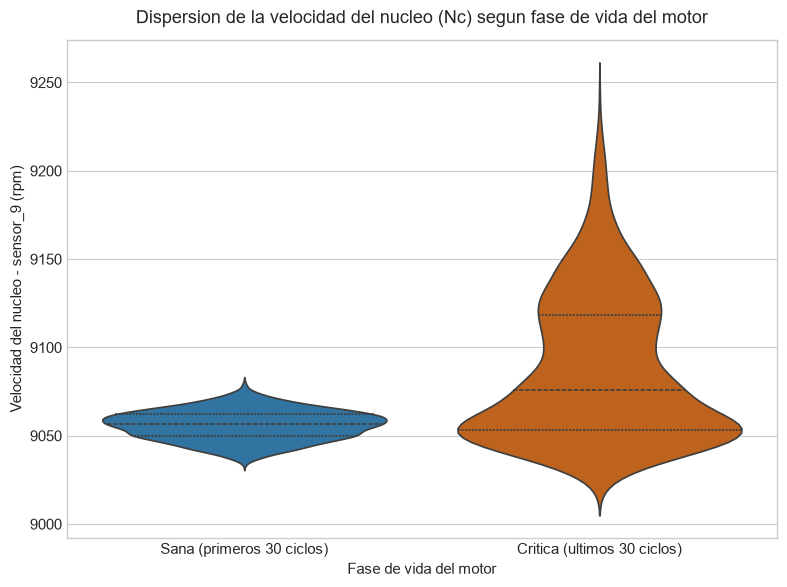

In [14]:
etiquetas = {'sana': 'Sana (primeros 30 ciclos)', 'critica': 'Critica (ultimos 30 ciclos)'}
df_plot = df_fases.copy()
df_plot['fase_label'] = df_plot['fase'].map(etiquetas)

paleta = {'Sana (primeros 30 ciclos)': COLOR_SANA, 'Critica (ultimos 30 ciclos)': COLOR_CRITICA}

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df_plot, x='fase_label', y='sensor_9', hue='fase_label', palette=paleta, legend=False, inner='quartile', ax=ax)

ax.set_title('Dispersion de la velocidad del nucleo (Nc) segun fase de vida del motor', fontsize=13, pad=12)
ax.set_xlabel('Fase de vida del motor')
ax.set_ylabel('Velocidad del nucleo - sensor_9 (rpm)')

plt.tight_layout()
plt.show()

El violin de fase sana del sensor_9 sale angosto, casi todo amontonado en un mismo valor. El de fase critica se ve bastante mas ancho, estirado sobre todo para arriba, y la linea del medio queda mas alta. Es lo mismo que salio en los numeros de arriba: el promedio sube algo, pero lo que mas cambia es el ancho, el desvio se multiplica por 4.94. Cerca de la falla el motor gira un poco mas rapido en promedio y, sobre todo, deja de girar parejo.

### Consulta 3.2: sensor_6 parece constante pero no lo es

`sensor_6` da relacion 0 en la tabla de comparacion de la Consulta 3.1, pero eso no significa que sea constante como los que ya saque en la seccion 2.2, ahi su desvio no daba exactamente cero. Reviso cuantos valores distintos toma en todo el dataset para entender que esta pasando.

In [15]:
valores_unicos = df[columnas_settings + columnas_sensores].nunique().sort_values()

print("--- Cantidad de valores distintos por columna (ordenado ascendente) ---")
print(valores_unicos)

--- Cantidad de valores distintos por columna (ordenado ascendente) ---
sensor_1        1
setting_3       1
sensor_5        1
sensor_10       1
sensor_18       1
sensor_19       1
sensor_16       1
sensor_6        2
sensor_17      13
setting_2      13
sensor_8       53
sensor_13      56
sensor_20     120
setting_1     158
sensor_11     159
sensor_2      310
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64


Aparece un salto grande despues de los constantes: `sensor_6` tiene muy pocos valores distintos, recien despues viene `sensor_17` con bastantes mas. Por eso su desvio (0.0014) no lo marca como constante en la seccion 2.2, tecnicamente si varia, pero casi no lo hace.

In [16]:
df_fases.groupby('fase')['sensor_6'].value_counts()

fase     sensor_6
critica  21.61       3000
sana     21.61       2866
         21.60        134
Name: count, dtype: int64

Confirmado: la fase critica tiene sus 3000 filas con el mismo valor (21.61), ni una sola vez aparece 21.60 ahi adentro. En cambio la fase sana si tiene los dos valores mezclados (2866 y 134 filas). Por eso el desvio de sensor_6 en critica da exactamente 0, no le llego ningun valor distinto para poder medir variacion.

### Consulta 3.3: la dispersion de sensor_9 sirve para estimar el RUL de un motor de test?

En la 3.1 vi que sensor_9 se pone mas inestable cerca de la falla, con un desvio 4.94 veces mayor en los ultimos 30 ciclos que en los primeros 30. 

Pero eso lo mire en train, donde ya se en que ciclo rompe cada motor y marcar la fase critica es facil. Quiero ver si sirve igual en test, contra el RUL real que da la NASA.

Las series de test no estan cortadas todas en el mismo punto, hay motores de los que veo 30 ciclos y otros de los que veo 300. Si calculo el desvio sobre la serie entera, el que tiene mas ciclos tiene mas chances de que sensor_9 se le mueva, y no porque este mas cerca de romper sino porque hay mas registros.

Por eso mido la dispersion sobre los ultimos 30 ciclos observados de cada motor, la misma cantidad para todos.

In [17]:
# cuanto se movio sensor_9 en los ultimos 30 ciclos que llegue a observar de cada motor
ultimos_30_test = test_df.groupby('unit_id').tail(CICLOS_FASE)
dispersion_test = ultimos_30_test.groupby('unit_id')['sensor_9'].std().rename('sensor_9_std').reset_index()

comparacion_dispersion = dispersion_test.merge(rul_df, on='unit_id', how='inner')
correlacion_dispersion = comparacion_dispersion['sensor_9_std'].corr(comparacion_dispersion['RUL'])

print(f"Motores cruzados contra RUL_FD001.txt: {comparacion_dispersion.shape[0]}")
print(f"Correlacion entre la dispersion de sensor_9 y el RUL real: {correlacion_dispersion:.3f}")

Motores cruzados contra RUL_FD001.txt: 100
Correlacion entre la dispersion de sensor_9 y el RUL real: -0.406


Da -0.406. El signo va para el lado esperado, cuanto mas se mueve sensor_9 en sus ultimos ciclos, menos vida le quedaba al motor.

Pero antes de decir que sirve lo quiero ver graficado, porque un solo numero puede esconder como se reparten los motores.

### Visualizacion de la Consulta 3.3: dispersion de sensor_9 contra el RUL real
Grafico un punto por motor de test: en el eje x la dispersion de sensor_9 en sus ultimos 30 ciclos observados, en el eje y el RUL real que da la NASA para ese motor.

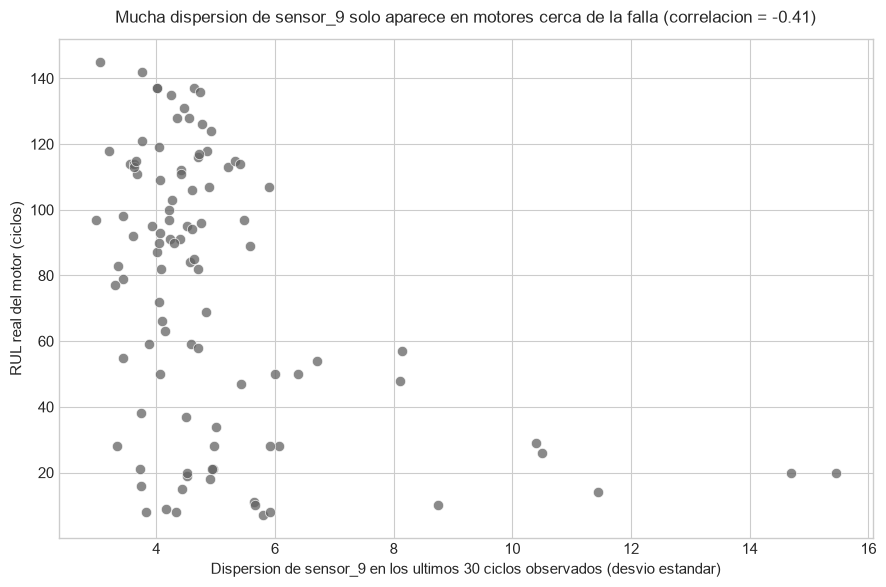

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(comparacion_dispersion['sensor_9_std'], comparacion_dispersion['RUL'],
           color=COLOR_NEUTRO, s=55, alpha=0.75, edgecolor='white', linewidth=0.6)

ax.set_title(f'Mucha dispersion de sensor_9 solo aparece en motores cerca de la falla (correlacion = {correlacion_dispersion:.2f})',
             fontsize=12.5, pad=12)
ax.set_xlabel('Dispersion de sensor_9 en los ultimos 30 ciclos observados (desvio estandar)')
ax.set_ylabel('RUL real del motor (ciclos)')

plt.tight_layout()
plt.show()

El grafico no dice lo que esperaba. La gran mayoria de los motores tiene una dispersion de entre 2 y 6, y ahi adentro hay de todo, desde motores con menos de 10 ciclos de RUL hasta otros con mas de 140. Un motor tranquilo puede estar recien arrancando o a punto de romper, no hay forma de saberlo.

Lo que si se ve es la cola de la derecha. Los pocos motores que pasan de 6 tienen todos menos de 60 ciclos de RUL.

Asi que sirve a medias. Si sensor_9 se sacude mucho, el motor esta cerca de romper. Si no se sacude, no dice nada. Va con lo de la 3.1, donde la dispersion se disparaba en el tramo final, pero no alcanza para estimar el RUL de cualquier motor.

### Consulta 3.4: que sensores dinamicos correlacionan mas con el RUL?

Hasta aca venia eligiendo sensores a mano (el 4, 11, 7 y 12) por lo que dice el paper sobre la falla del HPC. El tema es que nunca me puse a verificar si esa eleccion habia sido la mejor o si habia dejado afuera algun sensor mas util sin darme cuenta.

Para sacarme la duda lo encaro al reves. Agarro los 15 sensores dinamicos, calculo la correlacion de cada uno contra el rul usando todas las filas de train, y los ordeno de mayor a menor en valor absoluto, para ver si los datos respaldan lo que venia haciendo.

In [19]:
correlaciones_dict = {}
for sensor in sensores_dinamicos:
    correlaciones_dict[sensor] = df[sensor].corr(df['rul'])

correlaciones_rul = pd.Series(correlaciones_dict)

correlaciones_abs = correlaciones_rul.abs()
orden = correlaciones_abs.sort_values(ascending=False).index
correlaciones_rul = correlaciones_rul[orden]

print("Correlacion de cada sensor dinamico con el RUL (ordenado por valor absoluto):")
print(correlaciones_rul.round(3))

Correlacion de cada sensor dinamico con el RUL (ordenado por valor absoluto):
sensor_11   -0.696
sensor_4    -0.679
sensor_12    0.672
sensor_7     0.657
sensor_15   -0.643
sensor_21    0.636
sensor_20    0.629
sensor_2    -0.606
sensor_17   -0.606
sensor_3    -0.585
sensor_8    -0.564
sensor_13   -0.563
sensor_9    -0.390
sensor_14   -0.307
sensor_6    -0.128
dtype: float64


El resultado me dio que los cuatro primeros de la lista son exactamente los mismos que habia separado antes:

- sensor_11 (-0.696)
- sensor_4 (-0.679)
- sensor_12 (0.672)
- sensor_7 (0.657)

Lo mas llamativo aparece cuando miro los sensores anteriores:

- sensor_9 (-0.390)
- sensor_14 (-0.307)

En el analisis anterior eran los dos que mas aumentaban su dispersion al final de la vida del motor, pero aca caen casi al fondo de la tabla. 

Me parece que es por esto, aunque no estoy del todo seguro: la correlacion de Pearson solo mide si un sensor sube o baja en linea recta a medida que pasan los ciclos. 

En la 3.1 vi que sensor_9 si cambia de promedio, pero cerca de la falla oscila mas de lo que se corre. El corrimiento queda medio tapado por ese sacudon, y una cuenta lineal lo capta a medias.

Hay sensores que avisan la rotura solo moviendo su promedio y otros que ademas se vuelven inestables.

### Consulta 3.5: los motores que arrancan mas calientes duran menos?

Antes de meterme con el sensor_4 quiero ver primero cuanto dura un motor en general y cuanto cambia eso de uno a otro. En FD001 todos vuelan en la misma condicion, pero el readme aclara que cada motor arranca con un desgaste inicial y una variacion de fabricacion distinta, que no se conoce. No se cuanto pesa eso en la vida util, asi que lo miro antes de meterme con los sensores.

In [20]:
lifespans = df.groupby('unit_id')['cycle'].max()

print("--- Resumen Estadistico de Vida Util (Ciclos hasta la Falla) ---")
print(f"Media: {lifespans.mean():.2f} ciclos")
print(f"Desviacion Estandar: {lifespans.std():.2f} ciclos")
print(f"Minimo: {lifespans.min()} ciclos | Maximo: {lifespans.max()} ciclos")
print(f"Mediana (Q2): {lifespans.median()} ciclos")

--- Resumen Estadistico de Vida Util (Ciclos hasta la Falla) ---
Media: 206.31 ciclos
Desviacion Estandar: 46.34 ciclos
Minimo: 128 ciclos | Maximo: 362 ciclos
Mediana (Q2): 199.0 ciclos


El que mas duro llego a 362 ciclos y el que menos a 128, casi tres veces menos, con un desvio de 46 ciclos. 

Para motores que vuelan todos en la misma condicion es mucha diferencia.

No se si esa diferencia viene del desgaste inicial que menciona el readme o de otra cosa. 

El estado inicial del motor ya dice algo de cuanto va a durar? Un motor que arranca con sensor_4 (T50, la temperatura a la salida de la turbina de baja segun el paper) mas alto que el resto va a durar menos que uno que arranca mas fresco? Uso sensor_4 porque en la 3.4 quedo segundo en correlacion con el RUL (-0.679), y de los cuatro primeros es el unico que mide temperatura.

Calculo el promedio de sensor_4 en los primeros 30 ciclos de cada motor y luego comparo la vida util del 20% que arranca mas caliente contra el 20% que arranca mas fresco.

In [21]:
sensor_4_inicial = df[df['cycle'] <= CICLOS_FASE].groupby('unit_id')['sensor_4'].mean()
sensor_4_inicial.name = 'sensor_4_inicio'

tabla_inicio = pd.DataFrame({'sensor_4_inicio': sensor_4_inicial, 'vida_util': lifespans})
tabla_inicio = tabla_inicio.sort_values('sensor_4_inicio', ascending=False)

cantidad = int(len(tabla_inicio) * 0.2)

calientes = tabla_inicio.head(cantidad)
frescos = tabla_inicio.tail(cantidad)

print(f"Motores que arrancan con sensor_4 mas alto (20%):")
print(f"  Vida util promedio: {calientes['vida_util'].mean():.1f} ciclos")
print(f"Motores que arrancan con sensor_4 mas bajo (20%):")
print(f"  Vida util promedio: {frescos['vida_util'].mean():.1f} ciclos")
print(f"Diferencia: {frescos['vida_util'].mean() - calientes['vida_util'].mean():.1f} ciclos")

correlacion_inicio = tabla_inicio['sensor_4_inicio'].corr(tabla_inicio['vida_util'])
print(f"Correlacion entre sensor_4 al inicio y la vida util: {correlacion_inicio:.2f}")

Motores que arrancan con sensor_4 mas alto (20%):
  Vida util promedio: 195.6 ciclos
Motores que arrancan con sensor_4 mas bajo (20%):
  Vida util promedio: 232.6 ciclos
Diferencia: 37.0 ciclos
Correlacion entre sensor_4 al inicio y la vida util: -0.22


Hay diferencia, pero es floja. El 20% que arranca con sensor_4 mas alto dura 195.6 ciclos en promedio, contra 232.6 del 20% que arranca mas fresco, unos 37 ciclos menos. 

La correlacion entre el sensor_4 inicial y la vida util da -0.22, el signo va en la direccion esperada (arrancar mas caliente adelanta la falla) pero es una relacion debil.

## 4. Consultas en Spark

Todo lo anterior lo hice sobre FD001, que es el escenario mas controlado que hay en el repositorio: una sola condicion de vuelo y un solo modo de falla. Es una buena base pero tambien es el caso facil.

Ahora quiero levantar los 4 subdatasets juntos y ver que queda en pie. Son 160 mil filas contra las 20 mil de FD001, y cada consulta pasa a ser una comparacion entre escenarios en vez de una lectura directa.

Las consultas que siguen corren siempre sobre los 4 subdatasets a la vez.

### Arranque de la sesion de Spark
Levanto la sesion en modo local usando todos los nucleos disponibles.

In [22]:
import os
import sys

# Spark necesita una JVM: verificamos JAVA_HOME o buscamos el Java del sistema / Colab
if 'JAVA_HOME' not in os.environ or not os.path.exists(os.environ.get('JAVA_HOME', '')):
    for ruta in ['/usr/lib/jvm/default-java', '/usr/lib/jvm/java-17-openjdk-amd64', '/usr/lib/jvm/java-11-openjdk-amd64', r'C:\Program Files\Microsoft\jdk-17.0.20.101-hotspot']:
        if os.path.exists(ruta):
            os.environ['JAVA_HOME'] = ruta
            break
    else:
        try:
            import jdk4py
            os.environ['JAVA_HOME'] = str(jdk4py.JAVA_HOME)
        except ImportError:
            pass

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType

spark = (SparkSession.builder
         .appName('TP1_CMAPSS')
         .master('local[*]')
         .config('spark.sql.shuffle.partitions', '8')
         .config('spark.ui.showConsoleProgress', 'false')
         .getOrCreate())

sc = spark.sparkContext
sc.setLogLevel('ERROR')

print(f"Spark {spark.version} levantado en modo local con SparkContext: {sc}")

c:\Users\jorda\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark 4.2.0 levantado en modo local con SparkContext: <SparkContext master=local[*] appName=TP1_CMAPSS>


### Carga unificada de los 4 subdatasets
Conforme a la consigna de la materia, la API de DataFrames se utiliza únicamente para la lectura estructurada de los archivos crudos mediante `spark.read`, e inmediatamente convertimos cada dataset a RDD (`.rdd`) mapeando cada registro para incorporar la identificación del escenario (`dataset`). A partir de este punto, todo el procesamiento y las consultas se resuelven exclusivamente mediante transformaciones y acciones de la API de RDDs (`map`, `filter`, `reduceByKey`, `mapValues`, `join`, etc.).

El RUL tampoco viene en el archivo. Lo calculamos obteniendo el ciclo máximo de cada motor `(dataset, unit_id)` mediante `reduceByKey(max)`. Luego, distribuimos este mapeo de ciclos máximos mediante `sc.broadcast` e incorporamos el `rul = ciclo_max - cycle` a cada registro en el RDD.

Para la vida media de los motores calculamos el promedio de la vida útil de cada motor individual (`ciclo_max`), asegurando que coincida exactamente con la métrica calculada en Pandas (206.3 ciclos en FD001) y evitando el sesgo de promediar sobre el total de vuelos/filas.

In [23]:
columnas_sensores_spark = [f'sensor_{i}' for i in range(1, CANTIDAD_SENSORES + 1)]

campos = [StructField('unit_id', IntegerType()), StructField('cycle', IntegerType())]
for columna in ['setting_1', 'setting_2', 'setting_3'] + columnas_sensores_spark:
    campos.append(StructField(columna, DoubleType()))
esquema = StructType(campos)

SUBDATASETS = ['FD001', 'FD002', 'FD003', 'FD004']

# Lectura con DataFrame unicamente para la ingesta y conversion inmediata a RDD
rdds = []
for nombre in SUBDATASETS:
    df_raw = spark.read.option('sep', ' ').schema(esquema).csv(f'data/train_{nombre}.txt')
    # A partir de aca todo el procesamiento se realiza exclusivamente con la API de RDDs
    rdd_parte = df_raw.rdd.map(lambda r, ds=nombre: {
        'dataset': ds,
        'unit_id': r['unit_id'],
        'cycle': r['cycle'],
        'setting_1': r['setting_1'],
        'setting_2': r['setting_2'],
        'setting_3': r['setting_3'],
        **{f'sensor_{i}': r[f'sensor_{i}'] for i in range(1, CANTIDAD_SENSORES + 1)}
    })
    rdds.append(rdd_parte)

rdd_base = sc.union(rdds).cache()

# 1. Calculo de ciclo maximo por motor (dataset, unit_id) con RDD
# Clave: (dataset, unit_id), Valor: cycle
ciclos_max_rdd = (rdd_base
                  .map(lambda r: ((r['dataset'], r['unit_id']), r['cycle']))
                  .reduceByKey(max))

# 2. Resumen de carga: filas, motores y vida media calculados integramente con RDD
# a) Filas por dataset
filas_por_ds = rdd_base.map(lambda r: (r['dataset'], 1)).reduceByKey(lambda a, b: a + b)

# b) Motores y suma de vida util por dataset (1 entrada por motor en ciclos_max_rdd)
# Clave: dataset, Valor: (1 motor, ciclo_maximo)
stats_motores = (ciclos_max_rdd
                 .map(lambda item: (item[0][0], (1, item[1])))
                 .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])))

# c) Join de estadisticas y calculo de vida media real (promedio por motor)
resumen_carga = (filas_por_ds
                 .join(stats_motores)
                 .map(lambda item: (
                     item[0],
                     item[1][0],
                     item[1][1][0],
                     round(item[1][1][1] / item[1][1][0], 1)
                 ))
                 .sortBy(lambda x: x[0])
                 .collect())

# Presentacion en formato tabla
print(f"+{'-'*9}+{'-'*7}+{'-'*9}+{'-'*19}+")
print(f"|{'dataset':^9}|{'filas':^7}|{'motores':^9}|{'vida_media_ciclos':^19}|")
print(f"+{'-'*9}+{'-'*7}+{'-'*9}+{'-'*19}+")
for ds, f, m, vm in resumen_carga:
    print(f"|{ds:^9}|{f:^7}|{m:^9}|{vm:^19.1f}|")
print(f"+{'-'*9}+{'-'*7}+{'-'*9}+{'-'*19}+")
print(f"\nFilas totales cargadas: {rdd_base.count():,}")

# 3. Asignacion del RUL a cada registro en el RDD usando broadcast de ciclos_max
bc_ciclos_max = sc.broadcast(ciclos_max_rdd.collectAsMap())

def asignar_rul(r):
    reg = dict(r)
    max_c = bc_ciclos_max.value[(r['dataset'], r['unit_id'])]
    reg['rul'] = max_c - r['cycle']
    return reg

rdd = rdd_base.map(asignar_rul).cache()

Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 3.0 failed 1 times, most recent failure: Lost task 0.0 in stage 3.0 (TID 27) (Asus-Santiago executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed). Consider setting 'spark.sql.execution.pyspark.udf.faulthandler.enabled' or'spark.python.worker.faulthandler.enabled' configuration to 'true' for the better Python traceback.
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:704)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:686)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:35)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1068)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read

### 4.1 Consulta 1: el salto de dispersion de sensor_9 aparece tambien en los otros escenarios?

Uso lo de sensor_9 (la velocidad del nucleo), que en Pandas se movia 4.94 veces mas en los ultimos 30 ciclos que en los primeros 30. Es el numero mas fuerte que tengo hasta aca, asi que si algo va a cambiar entre un escenario y otro, deberia notarse justo ahi.

Hago la misma cuenta en los cuatro subdatasets.

In [ ]:
sensores_clave_spark = ['sensor_9']

# Filtramos fase sana y critica usando la transformacion filter del RDD
fase_sana = rdd.filter(lambda r: r['cycle'] <= CICLOS_FASE)
fase_critica = rdd.filter(lambda r: r['rul'] < CICLOS_FASE)

# Funcion pura de RDD para calcular el desvio estandar muestral por dataset
def calcular_desvio_rdd(rdd_filtrado, sensor):
    # Emite (dataset, (1, valor, valor^2)) y suma por clave con reduceByKey
    stats = (rdd_filtrado
             .map(lambda r: (r['dataset'], (1, float(r[sensor]), float(r[sensor]) ** 2)))
             .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2])))
    
    def a_desvio(item):
        ds, (n, sx, sxx) = item
        var = (sxx - (sx ** 2) / n) / (n - 1) if n > 1 else 0.0
        std = var ** 0.5 if var > 0 else 0.0
        return (ds, std)
        
    return stats.map(a_desvio)

desvios_s9_sana = calcular_desvio_rdd(fase_sana, 'sensor_9')
desvios_s9_critica = calcular_desvio_rdd(fase_critica, 'sensor_9')

# Join de RDDs por dataset y calculo del ratio critica / sana
dispersion_s9_rdd = (desvios_s9_sana
                     .join(desvios_s9_critica)
                     .map(lambda item: (
                         item[0],
                         round(item[1][0], 2),
                         round(item[1][1], 2),
                         round(item[1][1] / item[1][0], 3)
                     ))
                     .sortBy(lambda x: x[0]))

dispersion_s9_datos = dispersion_s9_rdd.collect()

print("Ratio de dispersion de sensor_9 (desvio fase critica / desvio fase sana) por subdataset:")
print(f"+{'-'*9}+{'-'*16}+")
print(f"|{'dataset':^9}|{'ratio_sensor_9':^16}|")
print(f"+{'-'*9}+{'-'*16}+")
for ds, _, _, ratio in dispersion_s9_datos:
    print(f"|{ds:^9}|{ratio:^16.3f}|")
print(f"+{'-'*9}+{'-'*16}+")

print("\nDesvio crudo de sensor_9 en cada fase, para ver de que magnitudes hablamos:")
print(f"+{'-'*9}+{'-'*13}+{'-'*16}+")
print(f"|{'dataset':^9}|{'desvio_sana':^13}|{'desvio_critica':^16}|")
print(f"+{'-'*9}+{'-'*13}+{'-'*16}+")
for ds, sana, crit, _ in dispersion_s9_datos:
    print(f"|{ds:^9}|{sana:^13.2f}|{crit:^16.2f}|")
print(f"+{'-'*9}+{'-'*13}+{'-'*16}+")

### Visualizacion de la Consulta 4.1: dispersion de sensor_9 en los 4 escenarios

Los ratios de arriba quedaron en una tabla y cuesta ver de un vistazo lo que esta pasando, asi que grafico los desvios crudos que hay detras de esos numeros.

In [ ]:
desvios_pd = pd.DataFrame(
    dispersion_s9_datos,
    columns=['dataset', 'sana_sensor_9', 'critica_sensor_9', 'ratio_sensor_9']
)

x = np.arange(len(desvios_pd))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - ancho / 2, desvios_pd['sana_sensor_9'], ancho, color=COLOR_SANA, label='Primeros 30 ciclos (sana)')
ax.bar(x + ancho / 2, desvios_pd['critica_sensor_9'], ancho, color=COLOR_CRITICA, label='Ultimos 30 ciclos (critica)')

ax.set_title('Dispersion de sensor_9 en fase sana y fase critica, por subdataset', fontsize=13)
ax.set_xlabel('Subdataset')
ax.set_ylabel('Desvio estandar de sensor_9 (rpm)')
ax.set_xticks(x)
ax.set_xticklabels(desvios_pd['dataset'])
ax.legend()

plt.tight_layout()
plt.show()

FD001 da 4.94 y FD003 da 3.47, en los dos se sacude bastante mas cerca de la falla. 

FD002 y FD004 dan 1.01, o sea que no pasa nada. No se cae en cualquier lado, se cae justo en los dos que vuelan en 6 condiciones distintas.

El desvio crudo da una pista. En FD001 sensor_9 se mueve 8.4 en fase sana y en FD002 se mueve 334, cuarenta veces mas, y eso que es la fase sana, donde todavia no hay desgaste. 

Segun el readme lo unico que cambia entre los dos es que FD002 vuela en 6 condiciones.

### 4.2 Consulta 2: que pasa con los otros sensores de la 3.1 en los otros escenarios?

En la 4.1 lleve sensor_9 a los 4 subdatasets. Ahora hago lo mismo con los otros cuatro sensores que venia mirando desde la 3.1 (sensor_4, sensor_11, sensor_7 y sensor_12), a ver como se comportan en los otros escenarios.

In [ ]:
otros_sensores = ['sensor_4', 'sensor_11', 'sensor_7', 'sensor_12']

def calcular_desvios_multiples_rdd(rdd_filtrado, sensores):
    def map_fila(r):
        return (r['dataset'], [(1, float(r[s]), float(r[s]) ** 2) for s in sensores])
        
    def reduce_stats(a, b):
        return [(a[i][0] + b[i][0], a[i][1] + b[i][1], a[i][2] + b[i][2]) for i in range(len(a))]
        
    stats = rdd_filtrado.map(map_fila).reduceByKey(reduce_stats)
    
    def a_desvios(item):
        ds, lista_stats = item
        desvios = {}
        for s, (n, sx, sxx) in zip(sensores, lista_stats):
            var = (sxx - (sx ** 2) / n) / (n - 1) if n > 1 else 0.0
            desvios[s] = var ** 0.5 if var > 0 else 0.0
        return (ds, desvios)
        
    return stats.map(a_desvios)

desvios_otros_sana = calcular_desvios_multiples_rdd(fase_sana, otros_sensores)
desvios_otros_critica = calcular_desvios_multiples_rdd(fase_critica, otros_sensores)

ratios_otros_rdd = (desvios_otros_sana
                    .join(desvios_otros_critica)
                    .map(lambda item: (
                        item[0],
                        {s: round(item[1][1][s] / item[1][0][s], 3) if item[1][0][s] > 0 else 0.0 for s in otros_sensores}
                    ))
                    .sortBy(lambda x: x[0]))

ratios_otros_datos = ratios_otros_rdd.collect()

print("Ratio de dispersion de los otros sensores clave (desvio fase critica / desvio fase sana) por subdataset:")
ancho_col = 16
encabezado_cols = "".join(f"|{f'ratio_{s}':^{ancho_col}}" for s in otros_sensores)
borde_cols = "".join(f"+{'-'*ancho_col}" for _ in otros_sensores)
print(f"+{'-'*9}{borde_cols}+")
print(f"|{'dataset':^9}{encabezado_cols}|")
print(f"+{'-'*9}{borde_cols}+")
for ds, d_ratios in ratios_otros_datos:
    linea_cols = "".join(f"|{d_ratios[s]:^{ancho_col}.3f}" for s in otros_sensores)
    print(f"|{ds:^9}{linea_cols}|")
print(f"+{'-'*9}{borde_cols}+")

# Integro los ratios de sensor_9 y de los otros sensores para la visualizacion
ratios_dict_por_ds = {ds: d_ratios for ds, d_ratios in ratios_otros_datos}
filas_tabla_ratios = []
for ds, _, _, r9 in dispersion_s9_datos:
    fila_r = {'dataset': ds, 'ratio_sensor_9': r9}
    for s in otros_sensores:
        fila_r[f'ratio_{s}'] = ratios_dict_por_ds[ds][s]
    filas_tabla_ratios.append(fila_r)

sensores_clave_spark = ['sensor_9'] + otros_sensores

### Visualizacion de la Consulta 4.2: relacion critica/sana de cada sensor en los 4 escenarios

La tabla de arriba son 16 numeros y cuesta ver el patron de un vistazo, asi que hago un grafico por sensor, cada uno con una barra por subdataset. Sumo sensor_9 de la 4.1 para tenerlo de referencia al lado.

Uso el mismo azul/naranja de siempre: naranja si la relacion pasa de 2, azul si queda cerca de 1.

In [ ]:
tabla_ratios = pd.DataFrame(filas_tabla_ratios)

UMBRAL_DISPARO = 2  # a partir de esta relacion, considero que el sensor se puso inestable

fig, axes = plt.subplots(1, len(sensores_clave_spark), figsize=(20, 4.5), sharey=True)

for ax, sensor in zip(axes, sensores_clave_spark):
    valores = tabla_ratios[f'ratio_{sensor}']
    colores = [COLOR_CRITICA if v > UMBRAL_DISPARO else COLOR_SANA for v in valores]
    ax.bar(tabla_ratios['dataset'], valores, color=colores)
    ax.axhline(1, color=COLOR_NEUTRO, linestyle='--', linewidth=1)
    ax.set_title(sensor)
    ax.set_xlabel('Subdataset')

axes[0].set_ylabel('Relacion desvio fase critica / fase sana')

leyenda = [
    plt.Rectangle((0, 0), 1, 1, color=COLOR_SANA, label='Se mantiene estable (<= 2x)'),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_CRITICA, label='Se dispara (> 2x)')
]
fig.legend(handles=leyenda, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))
fig.suptitle('Relacion de dispersion (fase critica / fase sana) de cada sensor clave, en los 4 escenarios', fontsize=13, y=1.15)

plt.tight_layout()
plt.show()

sensor_7 y sensor_12 se disparan solo en FD003 (naranja) y se quedan planos en FD001, FD002 y FD004. sensor_4 y sensor_11 no se disparan en ningun escenario.

FD001 y FD003 vuelan los dos en una sola condicion de vuelo, y segun el readme lo unico que cambia es que FD003 suma la falla del Fan. Por eso sospecho que el salto viene de esa falla. En FD004 tambien esta el Fan y no se ve, capaz por lo mismo de la 4.1: con 6 condiciones todo queda plano. No lo puedo confirmar.

### 4.3 Consulta 3: los sensores que mejor predicen el RUL son los mismos en los 4 escenarios?

En la Consulta 3.4 de Pandas rankee los sensores por correlacion con el RUL en FD001 y quedaron arriba sensor_11 (Ps30) y sensor_4 (T50), los dos cerca de -0.68.

Falta ver si ese ranking es una propiedad del motor o de FD001. Calculo la correlacion de los 21 sensores contra el RUL por separado en cada subdataset. Lo hago acumulando las sumas estadísticas de Pearson `(n, sum_y, sum_y2, sum_x, sum_x2, sum_xy)` de todos los sensores en una sola pasada con `mapPartitions` y `reduceByKey` sobre RDDs, sin repetir 21 veces el cálculo.

In [ ]:
# Calculo de correlacion de Pearson con el RUL para cada sensor usando la API de RDDs
def calc_corr_particion(iterator):
    acc = {}
    for r in iterator:
        ds = r['dataset']
        if ds not in acc:
            acc[ds] = {
                'n': 0, 'sy': 0.0, 'syy': 0.0,
                'sx': [0.0] * CANTIDAD_SENSORES,
                'sxx': [0.0] * CANTIDAD_SENSORES,
                'sxy': [0.0] * CANTIDAD_SENSORES
            }
        d = acc[ds]
        y = float(r['rul'])
        d['n'] += 1
        d['sy'] += y
        d['syy'] += y * y
        for i in range(CANTIDAD_SENSORES):
            x = float(r[f'sensor_{i+1}'])
            d['sx'][i] += x
            d['sxx'][i] += x * x
            d['sxy'][i] += x * y
    for ds, d in acc.items():
        yield (ds, d)

def reduce_corr(a, b):
    return {
        'n': a['n'] + b['n'],
        'sy': a['sy'] + b['sy'],
        'syy': a['syy'] + b['syy'],
        'sx': [a['sx'][i] + b['sx'][i] for i in range(CANTIDAD_SENSORES)],
        'sxx': [a['sxx'][i] + b['sxx'][i] for i in range(CANTIDAD_SENSORES)],
        'sxy': [a['sxy'][i] + b['sxy'][i] for i in range(CANTIDAD_SENSORES)],
    }

acc_total = rdd.mapPartitions(calc_corr_particion).reduceByKey(reduce_corr).collect()

tabla_corr_dict = {}
for ds, d in acc_total:
    n = d['n']
    sy = d['sy']
    syy = d['syy']
    var_y = (syy - (sy ** 2) / n)
    corrs = {}
    for i in range(CANTIDAD_SENSORES):
        s_name = f'sensor_{i+1}'
        sx = d['sx'][i]
        sxx = d['sxx'][i]
        sxy = d['sxy'][i]
        var_x = (sxx - (sx ** 2) / n)
        std_x = (var_x / (n - 1)) ** 0.5 if n > 1 and var_x > 0 else 0.0
        if std_x > UMBRAL_CONSTANTE and var_x > 0 and var_y > 0:
            num = n * sxy - sx * sy
            den = (var_x * var_y) ** 0.5
            r_val = round(num / den, 3)
            corrs[s_name] = r_val
        else:
            corrs[s_name] = np.nan
    tabla_corr_dict[ds] = corrs

tabla_corr = pd.DataFrame(tabla_corr_dict)[SUBDATASETS]

print("Correlacion de cada sensor con el RUL, por subdataset (NaN = sensor constante):")
print(tabla_corr.to_string())

print()
print("Top 5 sensores por subdataset (ordenado por valor absoluto):")
for nombre in SUBDATASETS:
    ranking = tabla_corr[nombre].dropna().abs().sort_values(ascending=False).head(5)
    valores = tabla_corr[nombre].reindex(ranking.index)
    print(f"  {nombre}: " + ", ".join(f"{s} ({v:+.3f})" for s, v in valores.items()))

En FD001 y FD003 el ranking es casi el mismo: gana sensor_11 (-0.696 y -0.689) y segundo sale sensor_4 (-0.679 y -0.657). Lo que elegi en la 3.4 se sostiene en el otro escenario de una sola condicion de vuelo.

En FD002 y FD004 se cae. La correlacion mas fuerte es -0.078, y sensor_11 baja a -0.047 y -0.057. Con la lectura cruda ningun sensor muestra relacion con el RUL.



### 4.4 Consulta 4: si agrupo los vuelos segun cuanto le falta al motor para romper, aparece el desgaste de sensor_11 en los 4 escenarios?

En la 4.1 y en la 4.3 pasa lo mismo: lo que funciona en FD001 y FD003 se cae justo en FD002 y FD004, como si esos motores no se gastaran. Y en la 4.1 los sensores de esos dos escenarios se movian muchisimo aunque el motor estuviera sano (sensor_9 variaba 334 contra 8.4 en FD001).

Segun el readme, lo unico que tienen distinto esos dos es que vuelan en 6 condiciones en vez de una, y el mismo readme avisa que los tres settings tienen un efecto grande en el funcionamiento del motor. Asi que sospecho de los settings. Para ver que pasa, miro los primeros vuelos de un motor de FD002 con sus tres settings y sensor_11.

In [ ]:
primeros_vuelos = (rdd
                   .filter(lambda r: r['dataset'] == 'FD002' and r['unit_id'] == 1)
                   .map(lambda r: (r['cycle'], r['setting_1'], r['setting_2'], r['setting_3'], r['sensor_11']))
                   .sortBy(lambda x: x[0])
                   .take(8))

print(f"+{'-'*7}+{'-'*11}+{'-'*11}+{'-'*11}+{'-'*11}+")
print(f"|{'cycle':^7}|{'setting_1':^11}|{'setting_2':^11}|{'setting_3':^11}|{'sensor_11':^11}|")
print(f"+{'-'*7}+{'-'*11}+{'-'*11}+{'-'*11}+{'-'*11}+")
for c, s1, s2, s3, s11 in primeros_vuelos:
    print(f"|{c:^7}|{s1:^11.4f}|{s2:^11.4f}|{s3:^11.1f}|{s11:^11.2f}|")
print(f"+{'-'*7}+{'-'*11}+{'-'*11}+{'-'*11}+{'-'*11}+")

Los tres settings cambian casi en cada vuelo, y cambian juntos: el motor pasa de 35 mil pies, Mach 0.84 y palanca en 100, a 25 mil pies, Mach 0.62 y palanca en 60. Los valores traen un poco de ruido en los decimales, 34.9983 es 35 mil pies. Coincide con lo que dice el paper, que el mismo motor puede volar en una condicion distinta en cada vuelo. Y sensor_11 salta con ellos: marca 42 en un vuelo y 36.7 en el siguiente. Son saltos de 5 puntos entre vuelos seguidos, cuando en FD001 sensor_11 se movia menos de un punto entre fase sana y critica (de 47.36 a 47.97 en la 3.1). La correlacion mira vuelo por vuelo, y con saltos asi no tiene forma de ver el desgaste.

Pruebo promediar muchos vuelos juntos, a ver si los saltos se compensan. Junto los vuelos en tramos de 30 ciclos segun cuanto le faltaba al motor para romper (el tramo 0 son los ultimos 30 ciclos, el 30 los 30 anteriores, y asi) y promedio sensor_11 en cada tramo. Llego hasta el tramo 150, porque mas lejos de la falla van quedando pocos motores.

In [ ]:
TRAMO_MAXIMO = 150

# Calculo de promedios de sensor_11 por tramo de RUL usando la API de RDDs
curva_s11_rdd = (rdd
                 .map(lambda r: ((int(r['rul'] // CICLOS_FASE * CICLOS_FASE), r['dataset']), (1, float(r['sensor_11']))))
                 .filter(lambda item: item[0][0] <= TRAMO_MAXIMO)
                 .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
                 .mapValues(lambda v: round(v[1] / v[0], 2)))

res_s11 = dict(curva_s11_rdd.collect())
tramos_unicos = sorted(set(t for t, ds in res_s11.keys()), reverse=True)

filas_s11 = []
for t in tramos_unicos:
    fila = {'tramo_rul': t}
    for ds in SUBDATASETS:
        fila[ds] = res_s11.get((t, ds), np.nan)
    filas_s11.append(fila)

curva_pd = pd.DataFrame(filas_s11)

print("Promedio de sensor_11 por tramo de RUL, en cada escenario:")
print(f"+{'-'*11}+{'-'*7}+{'-'*7}+{'-'*7}+{'-'*7}+")
print(f"|{'tramo_rul':^11}|{'FD001':^7}|{'FD002':^7}|{'FD003':^7}|{'FD004':^7}|")
print(f"+{'-'*11}+{'-'*7}+{'-'*7}+{'-'*7}+{'-'*7}+")
for _, row in curva_pd.iterrows():
    print(f"|{int(row['tramo_rul']):^11}|{row['FD001']:^7.2f}|{row['FD002']:^7.2f}|{row['FD003']:^7.2f}|{row['FD004']:^7.2f}|")
print(f"+{'-'*11}+{'-'*7}+{'-'*7}+{'-'*7}+{'-'*7}+\n")

for nombre in SUBDATASETS:
    subida = curva_pd[nombre].iloc[-1] - curva_pd[nombre].iloc[0]
    print(f"{nombre}: sube {subida:.2f} del tramo {TRAMO_MAXIMO} al tramo 0")

Hago un control. Si cerca del final los motores volaran a otras alturas, el promedio se moveria por eso y no por el desgaste. Para descartarlo miro la altura promedio de los vuelos (setting_1) en cada tramo.

In [ ]:
# Control de altitud (setting_1) por tramo de RUL usando la API de RDDs
altitud_rdd = (rdd
               .map(lambda r: ((int(r['rul'] // CICLOS_FASE * CICLOS_FASE), r['dataset']), (1, float(r['setting_1']))))
               .filter(lambda item: item[0][0] <= TRAMO_MAXIMO)
               .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
               .mapValues(lambda v: round(v[1] / v[0], 2)))

res_altitud = dict(altitud_rdd.collect())

filas_alt = []
for t in tramos_unicos:
    fila = {'tramo_rul': t}
    for ds in SUBDATASETS:
        fila[ds] = res_altitud.get((t, ds), np.nan)
    filas_alt.append(fila)

control_altitud_pd = pd.DataFrame(filas_alt)

print("Control: altitud promedio de los vuelos (miles de pies) por tramo de RUL, en cada escenario:")
print(f"+{'-'*11}+{'-'*7}+{'-'*7}+{'-'*7}+{'-'*7}+")
print(f"|{'tramo_rul':^11}|{'FD001':^7}|{'FD002':^7}|{'FD003':^7}|{'FD004':^7}|")
print(f"+{'-'*11}+{'-'*7}+{'-'*7}+{'-'*7}+{'-'*7}+")
for _, row in control_altitud_pd.iterrows():
    print(f"|{int(row['tramo_rul']):^11}|{row['FD001']:^7.2f}|{row['FD002']:^7.2f}|{row['FD003']:^7.2f}|{row['FD004']:^7.2f}|")
print(f"+{'-'*11}+{'-'*7}+{'-'*7}+{'-'*7}+{'-'*7}+")

FD001 y FD003 andan en 47 y FD002 y FD004 en 43, asi que a cada escenario le resto su promedio del tramo 150. Todos arrancan en cero y se ve directo cuanto sube cada uno.

Azul para los escenarios de una condicion de vuelo y naranja para los de 6. Linea llena para una falla y punteada para dos.

In [ ]:
colores = {'FD001': COLOR_SANA, 'FD002': COLOR_CRITICA, 'FD003': COLOR_SANA, 'FD004': COLOR_CRITICA}
lineas = {'FD001': '-', 'FD002': '-', 'FD003': '--', 'FD004': '--'}
etiquetas = {'FD001': 'FD001 (1 condicion, 1 falla)', 'FD002': 'FD002 (6 condiciones, 1 falla)',
             'FD003': 'FD003 (1 condicion, 2 fallas)', 'FD004': 'FD004 (6 condiciones, 2 fallas)'}

fig, ax = plt.subplots(figsize=(10, 6))

for nombre in SUBDATASETS:
    subida = curva_pd[nombre] - curva_pd[nombre].iloc[0]
    ax.plot(curva_pd['tramo_rul'], subida, marker='o', linewidth=2,
            color=colores[nombre], linestyle=lineas[nombre], label=etiquetas[nombre])

ax.set_xticks(curva_pd['tramo_rul'])
ax.invert_xaxis()
ax.set_title('Promediando por tramos, sensor_11 sube casi igual en los 4 escenarios', fontsize=13)
ax.set_xlabel('Ciclos que le faltan al motor para romper (tramos de 30 ciclos)')
ax.set_ylabel(f'Cuanto subio sensor_11 desde el tramo {TRAMO_MAXIMO} (psia)')
ax.legend()

plt.tight_layout()
plt.show()

Aparece. En los 4 escenarios sensor_11 sube a medida que el motor se acerca a romper: 0.59 en FD001, 0.51 en FD002, 0.68 en FD003 y 0.63 en FD004. En FD002 y FD004, donde la correlacion daba casi cero, sube casi lo mismo que en FD001.

El control da bien. La altura promedio de los vuelos es la misma en todos los tramos (24 mil pies en FD002 y FD004, nivel del mar en FD001 y FD003), asi que la subida no viene de volar distinto, es desgaste.

El desgaste siempre estuvo, vuelo por vuelo lo tapaban los saltos de las condiciones de vuelo. Y no sube parejo, casi toda la subida pasa en los ultimos tramos.

In [ ]:
spark.stop()
print("Sesion de Spark cerrada.")

## 5. Conclusiones principales

Arranque este TP sin saber nada de motores, asi que lo que mas me llevo no es un numero puntual, es una forma de mirar los datos que antes no tenia.

Lo primero que aprendi es que un numero solo no dice nada. En la 2.3 el desvio de sensor_9 en crudo parecia de los mas grandes, pero en proporcion a su promedio era de los mas chicos. Y en la 3.1, comparando los primeros ciclos contra los ultimos antes de romper, su desvio subia casi 5 veces. Sin esos contrastes no me daba cuenta de nada.

Lo segundo es que en un sensor no solo importa el promedio, importa cuanto se mueve. sensor_11 y sensor_4 avisan la falla porque su promedio cambia. sensor_9 tambien mueve el promedio, pero ademas empieza a oscilar fuerte, y ese sacudon tambien es una alarma, solo que distinta.

Lo que mas me sorprendio fue lo de FD002 y FD004. Ahi los motores vuelan en condiciones bien distintas y mirando sensor_11 fila por fila no se veia nada, la correlacion daba casi cero. Pero agrupando los vuelos segun cuanto le faltaba al motor para romper aparecia el mismo patron de desgaste que en FD001. El dato estaba, lo tapaba el ruido de las distintas condiciones de vuelo.

Tambien me quedo que lo que funciona en un escenario no funciona siempre. Lo que encontre en FD001 mirando vuelo por vuelo se repitio en FD003 pero no en FD002 ni FD004, hasta que cambie la forma de agrupar. Si me quedaba solo mirando FD001 me perdia esa parte.

Y aprendi a no confiar tanto en la correlacion sola porque asume que todo cambia en linea recta, y el desgaste del motor no es asi, se acelera cerca del final. Creo que por eso sensor_9, que avisa a su manera con su variabilidad, quedo mal rankeado si solo mido correlacion lineal.

Me quedaron cosas sin cerrar, como por que sensor_7 y sensor_12 se comportan distinto entre FD003 y FD004 teniendo el mismo modo de falla.